In [1]:
# Standard
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Own
from intersession import glue_animals_intersessions
from my_fun import *
from psychometric_curves import *

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
# Plotting style
# sns.set_theme()
sns.set_style('ticks')
sns.set_context('poster')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'retina'

# Analyses of drug data from batch #6

In [4]:
# Set parameters
experiment = '2AFC_6'  # Set the experiment (batch)
animals = ['014', '016', '017', '020', '021', '022', '023', '024', '025']

In [5]:
# Load intersession data
df_intersessions = glue_animals_intersessions(experiment=experiment, filter_drug=True, update=False, to_csv=False)

glue_animals_intersessions took 0.16 seconds to run


## Behavioral metrics

In [6]:
# Define function to compare behavioral metrics between saline and drug conditions

def plot_var_drug(df_intersessions, var_name='Accuracy'):
    """
    Plot a variable (e.g., accuracy) for each subject and drug condition together with the mean and sem across subjects, and run a t-test between saline and drug conditions.
    :param df_intersessions: DataFrame containing intersession data from all animals
    :param var_name: Name of the variable to plot (e.g., 'Accuracy')
    :return: None
    """

    var = df_intersessions.groupby(['Subject', 'Drug'])[var_name].mean().reset_index()
    var_mean = var.groupby('Drug')[var_name].mean()
    var_sem = var.groupby('Drug')[var_name].sem()

    # Plot paired lines
    # plt.figure(constrained_layout=True)
    default_fig_size = np.array(plt.rcParams['figure.figsize'])
    plt.figure(figsize=default_fig_size/2, constrained_layout=True)
    sns.lineplot(data=var, x='Drug', y=var_name, hue='Subject', marker='o', palette=['gray'] * var.Subject.nunique(), alpha=0.25, legend=False)
    # Plot mean and SEM
    plt.errorbar(x=var_mean.index, y=var_mean.values, yerr=var_sem.values, fmt='-o', color='k')
    # plt.title(var_name)
    plt.ylabel(var_name)
    # plt.ylim([0.5, 1])
    plt.xticks([0, 1], ['Saline', 'Drug'])
    plt.xlabel('')
    sns.despine()

    # Run t-test
    saline = var[var['Drug'] == 0][var_name]
    drug = var[var['Drug'] == 1][var_name]
    t_stat, p_val = ttest_ind(saline, drug)
    print(f"Accuracy: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")
    add_star_between(p_val)

Accuracy: t-statistic = 2.951, p-value = 0.009
Accuracy: t-statistic = 3.191, p-value = 0.006
Accuracy: t-statistic = -0.613, p-value = 0.548
Accuracy: t-statistic = 0.065, p-value = 0.949
Accuracy: t-statistic = -4.027, p-value = 0.001


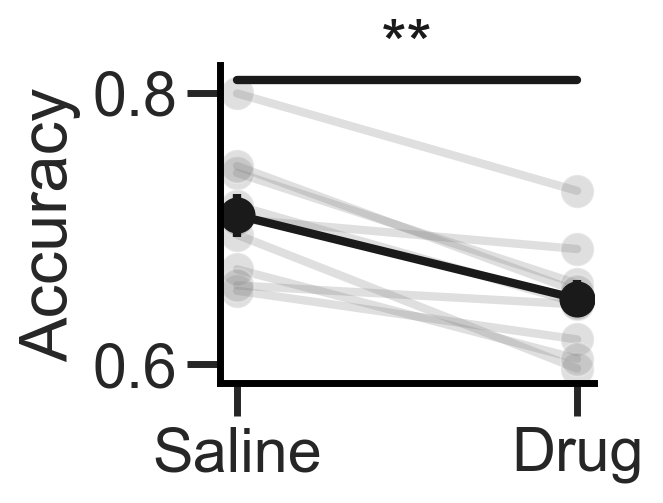

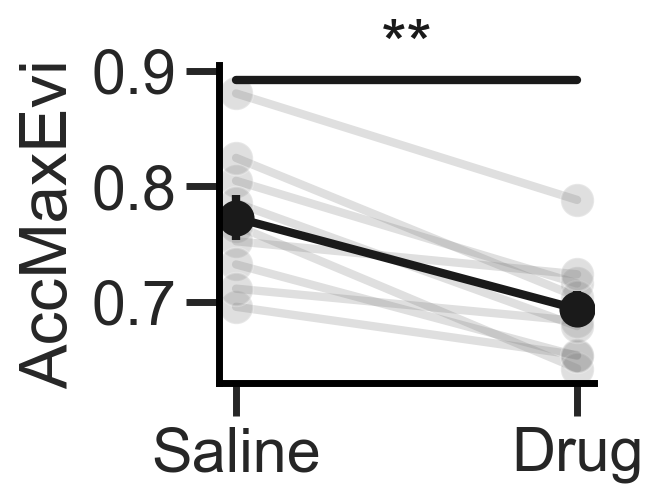

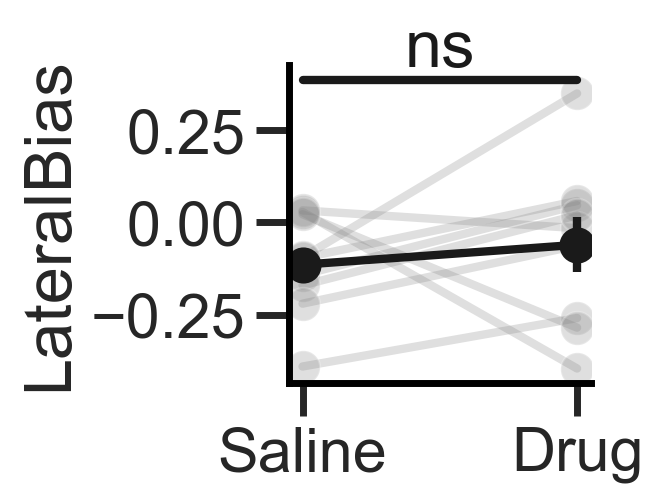

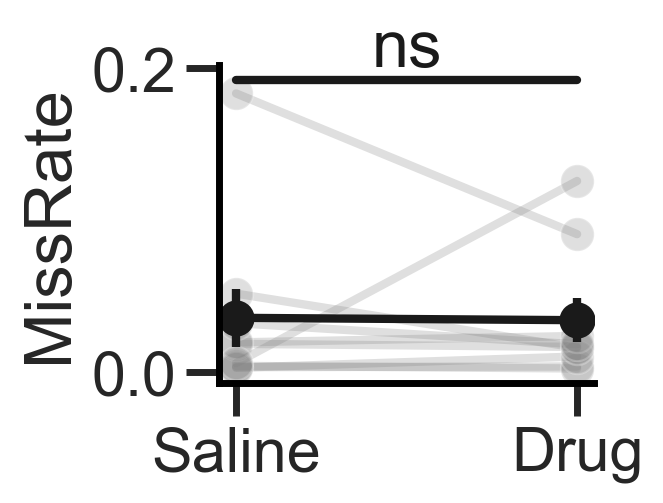

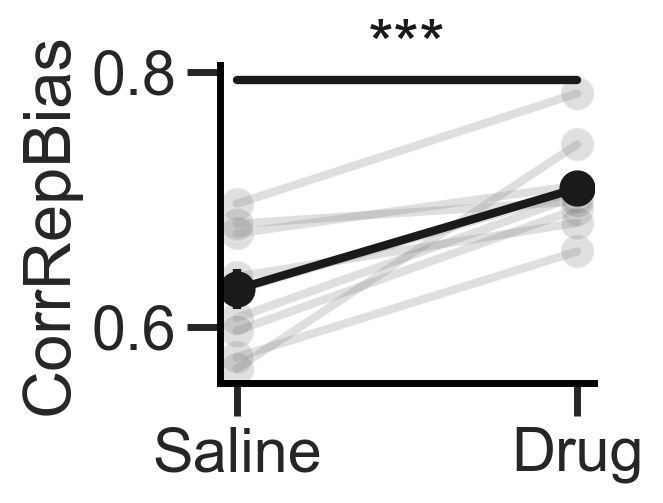

In [7]:
plot_var_drug(df_intersessions, var_name='Accuracy')
plot_var_drug(df_intersessions, var_name='AccMaxEvi')
plot_var_drug(df_intersessions, var_name='LateralBias')
plot_var_drug(df_intersessions, var_name='MissRate')
plot_var_drug(df_intersessions, var_name='CorrRepBias')

## Psychometrics

In [17]:
def compare_psych_params(params, param_name):
    """
    Compare the parameters of the saline and drug conditions.
    """

    # Plot seaborn boxplot comparing parameters
    # plt.figure(constrained_layout=True)
    default_fig_size = np.array(plt.rcParams['figure.figsize'])
    plt.figure(figsize=default_fig_size/2, constrained_layout=True)
    sns.boxplot(data=params, x='drug', y=param_name, hue='drug', palette=['tab:gray', 'tab:pink'], linewidth=2.5, showfliers=False, legend=False)
    # sns.swarmplot(data=params, x='drug', y=param_name, color='k', legend=False)
    plt.xticks([0, 1], ['Saline', 'Drug'])
    plt.xlabel('')
    sns.despine()

    saline = params[params['drug'] == 0][param_name]
    drug = params[params['drug'] == 1][param_name]

    t_stat, p_val = ttest_ind(saline, drug)
    print(f"{param_name}: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")

    add_star_between(p_val)

### Probability choose RIGHT

In [9]:
kind= 'prob_right'

#### Single animals

Animal 014
plot_pc took 1.09 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 1.02 seconds to run
plot_pc_drug took 2.13 seconds to run
Animal 016
plot_pc took 1.12 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 1.10 seconds to run
plot_pc_drug took 2.25 seconds to run
Animal 017
plot_pc took 1.19 seconds to run


...

plot_pc took 1.04 seconds to run
plot_pc_drug took 1.96 seconds to run
Animal 024
plot_pc took 0.96 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 0.96 seconds to run
plot_pc_drug took 1.95 seconds to run
Animal 025
plot_pc took 0.87 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 0.83 seconds to run
plot_pc_drug took 1.72 seconds to run


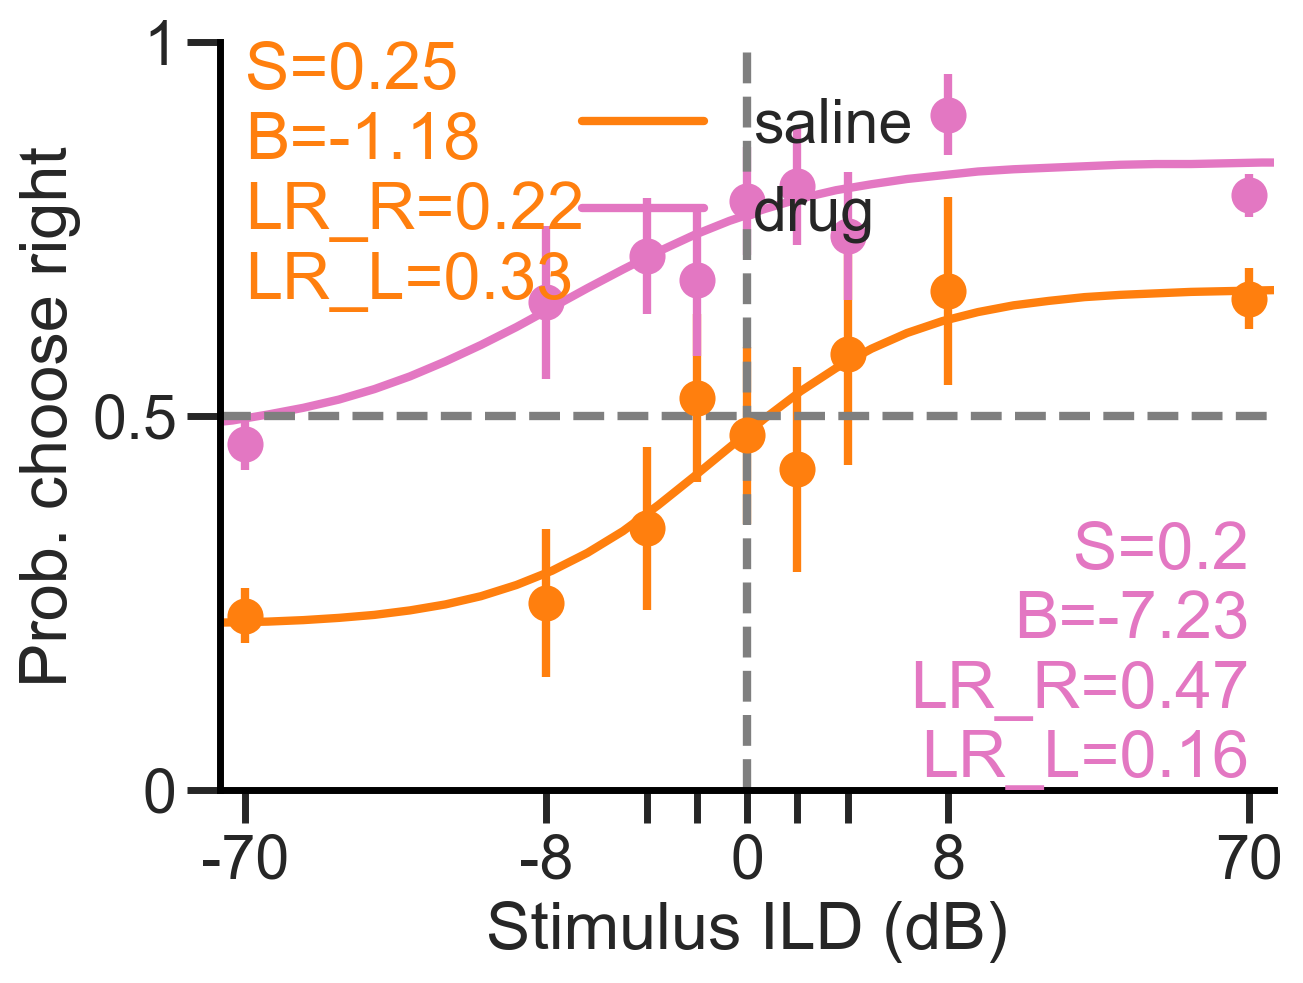

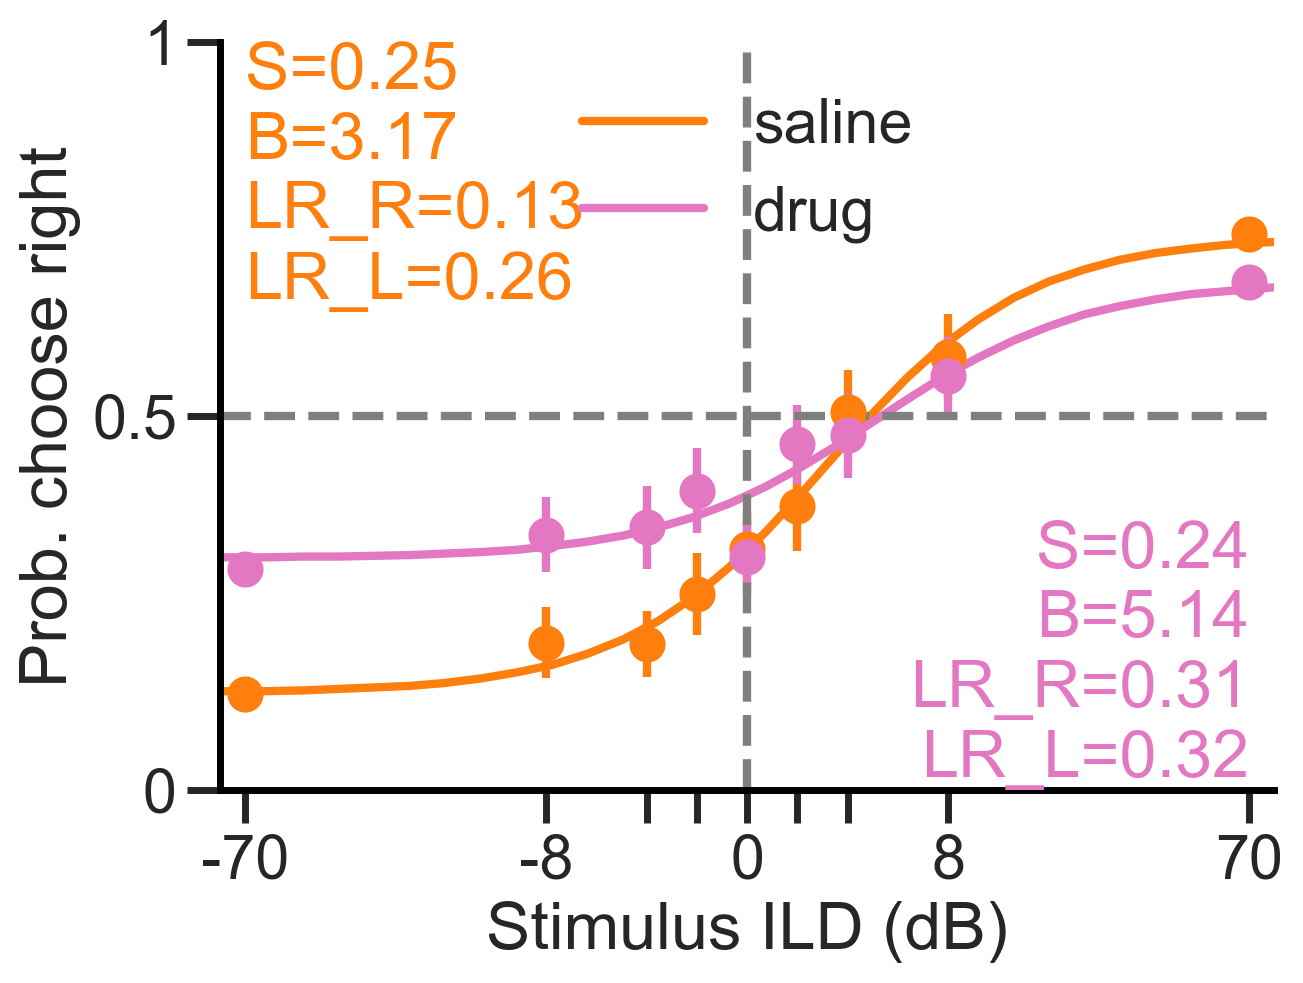

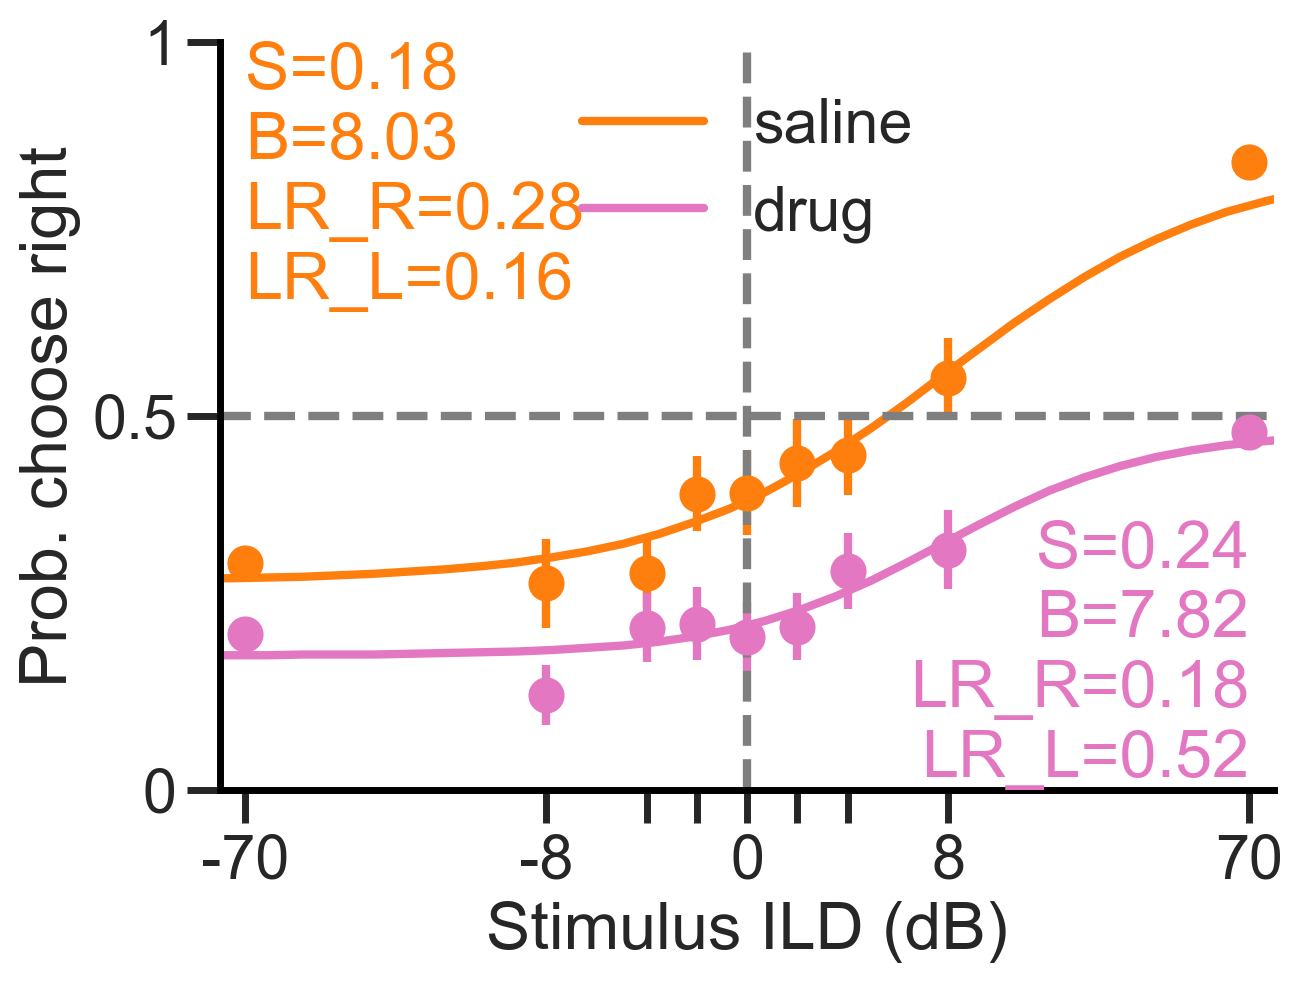

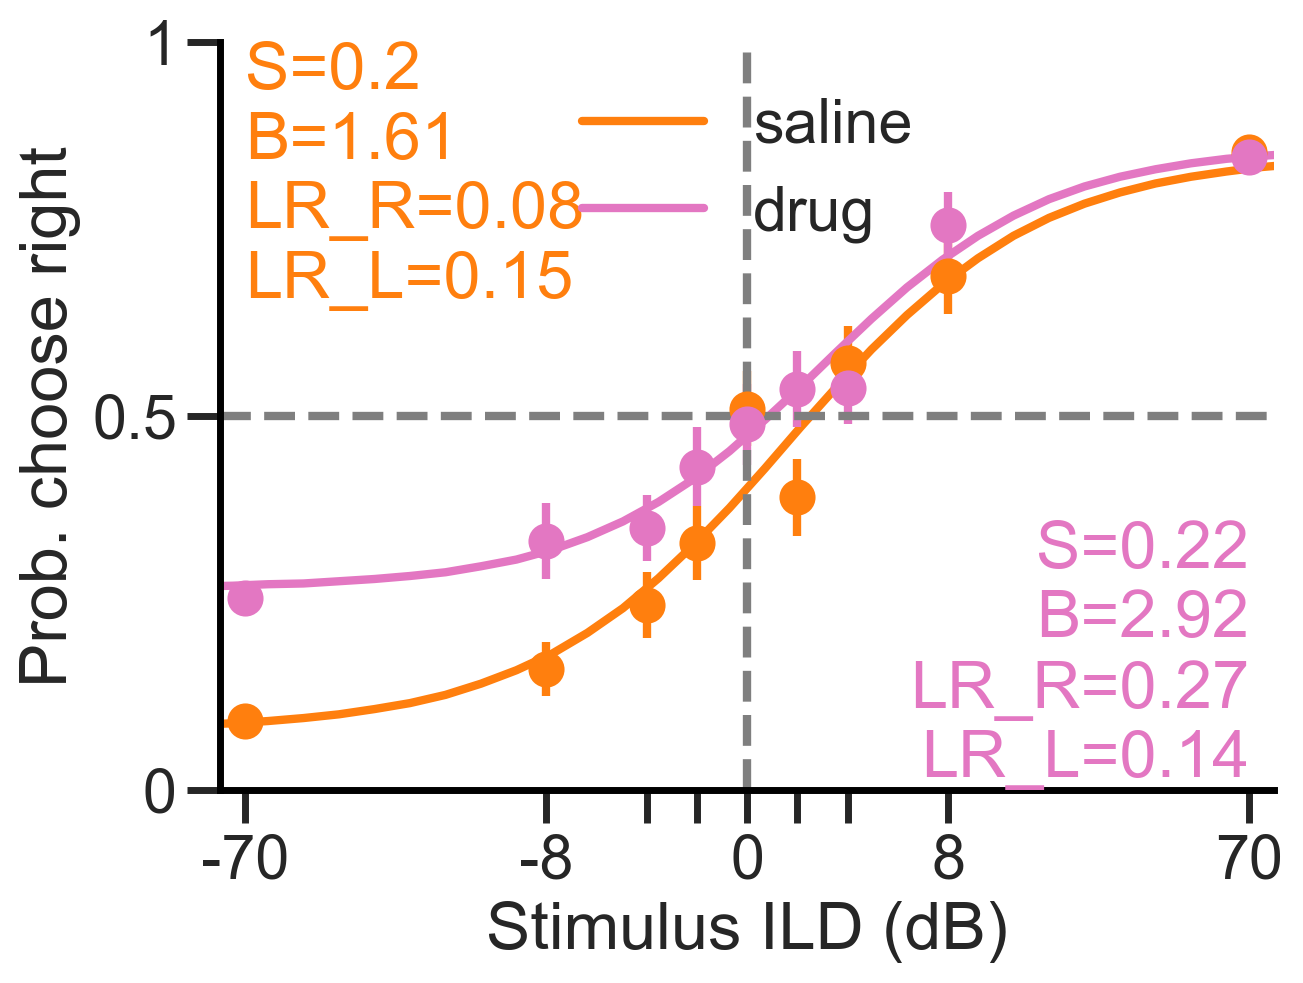

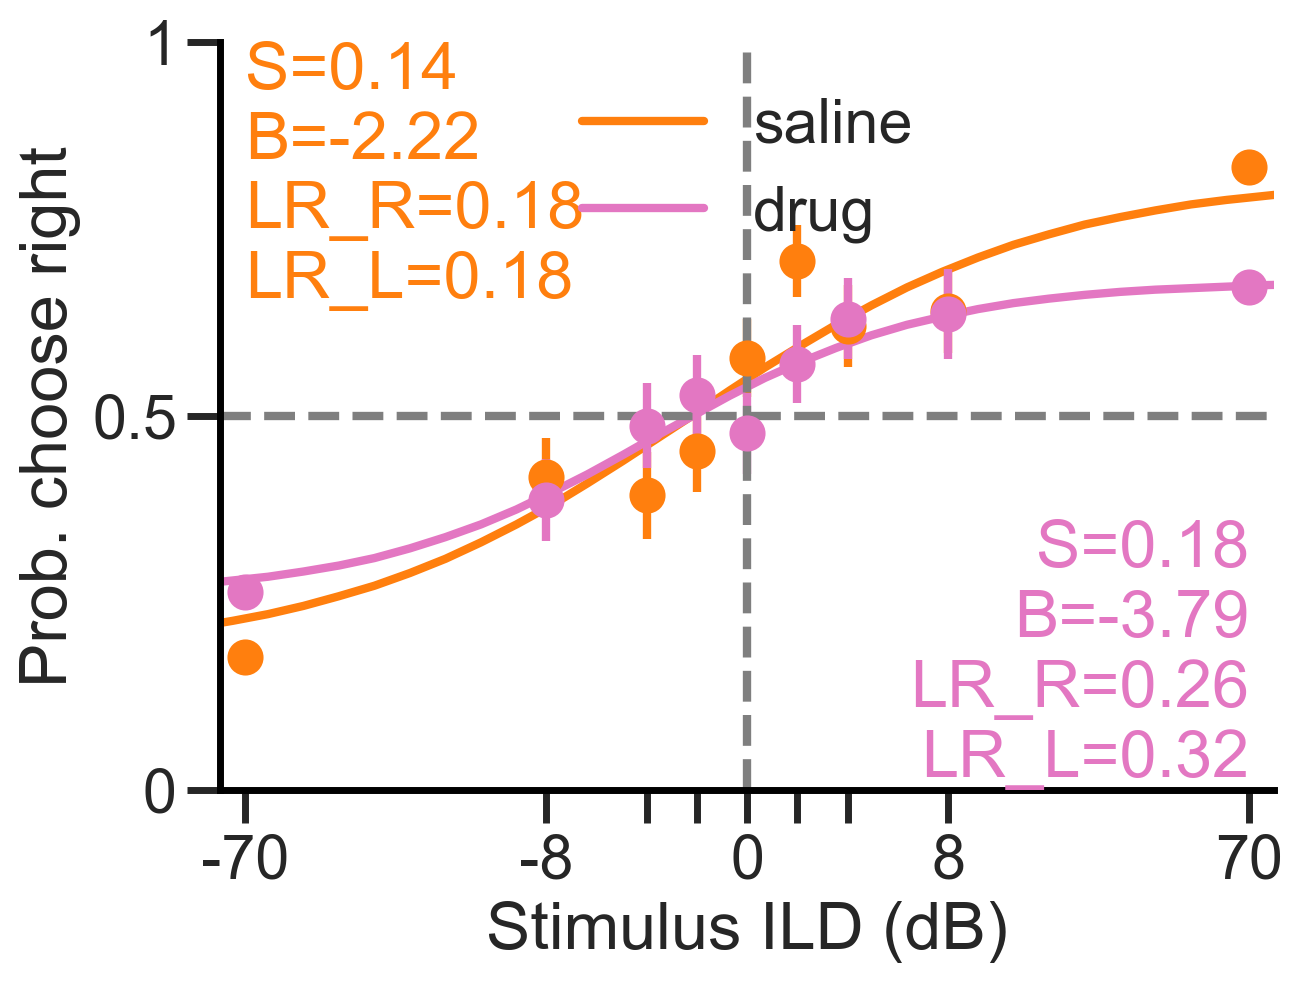

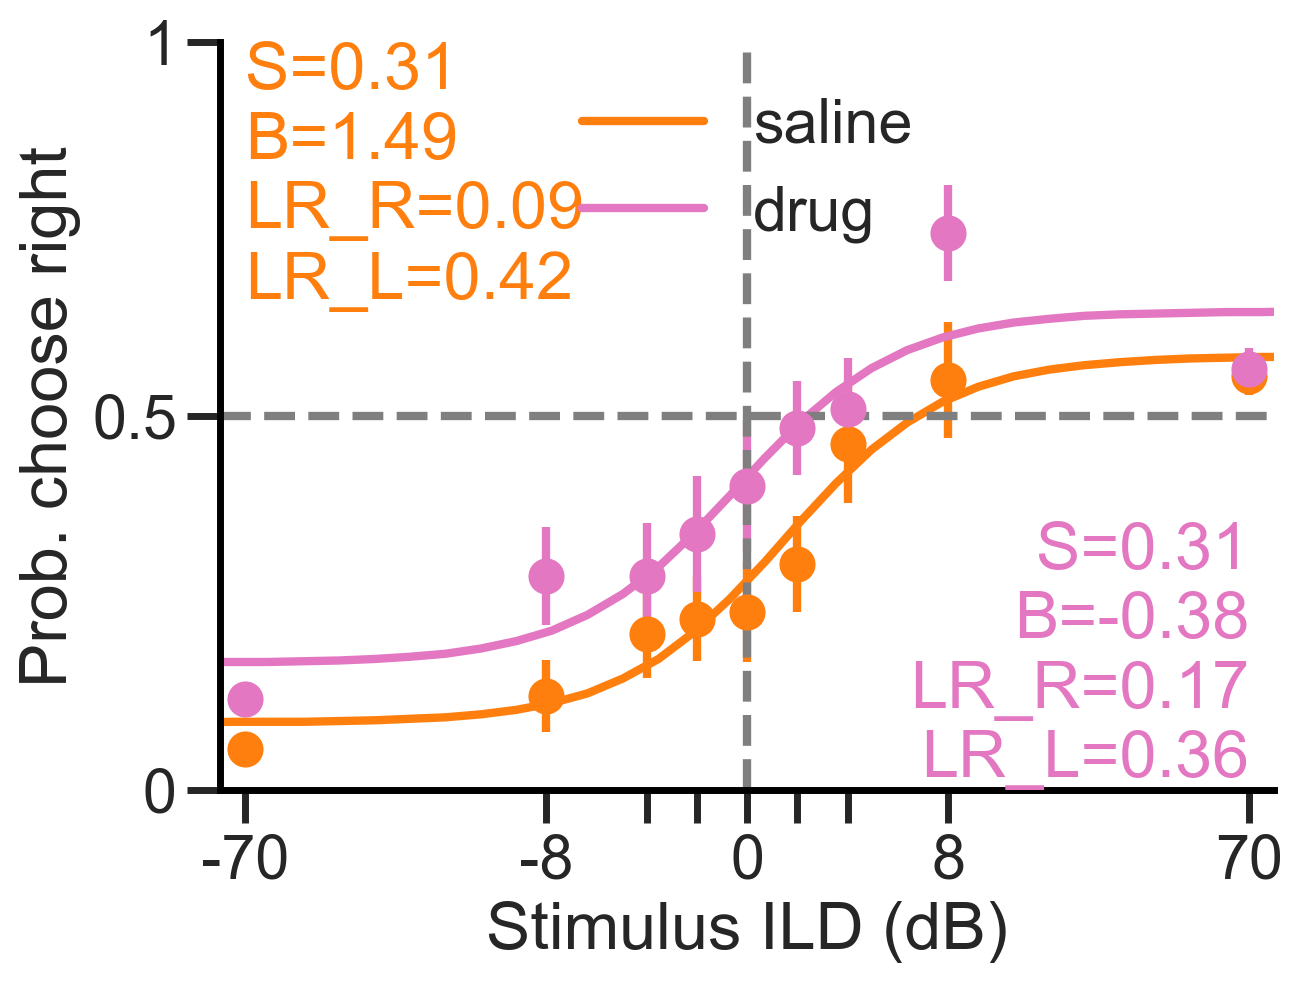

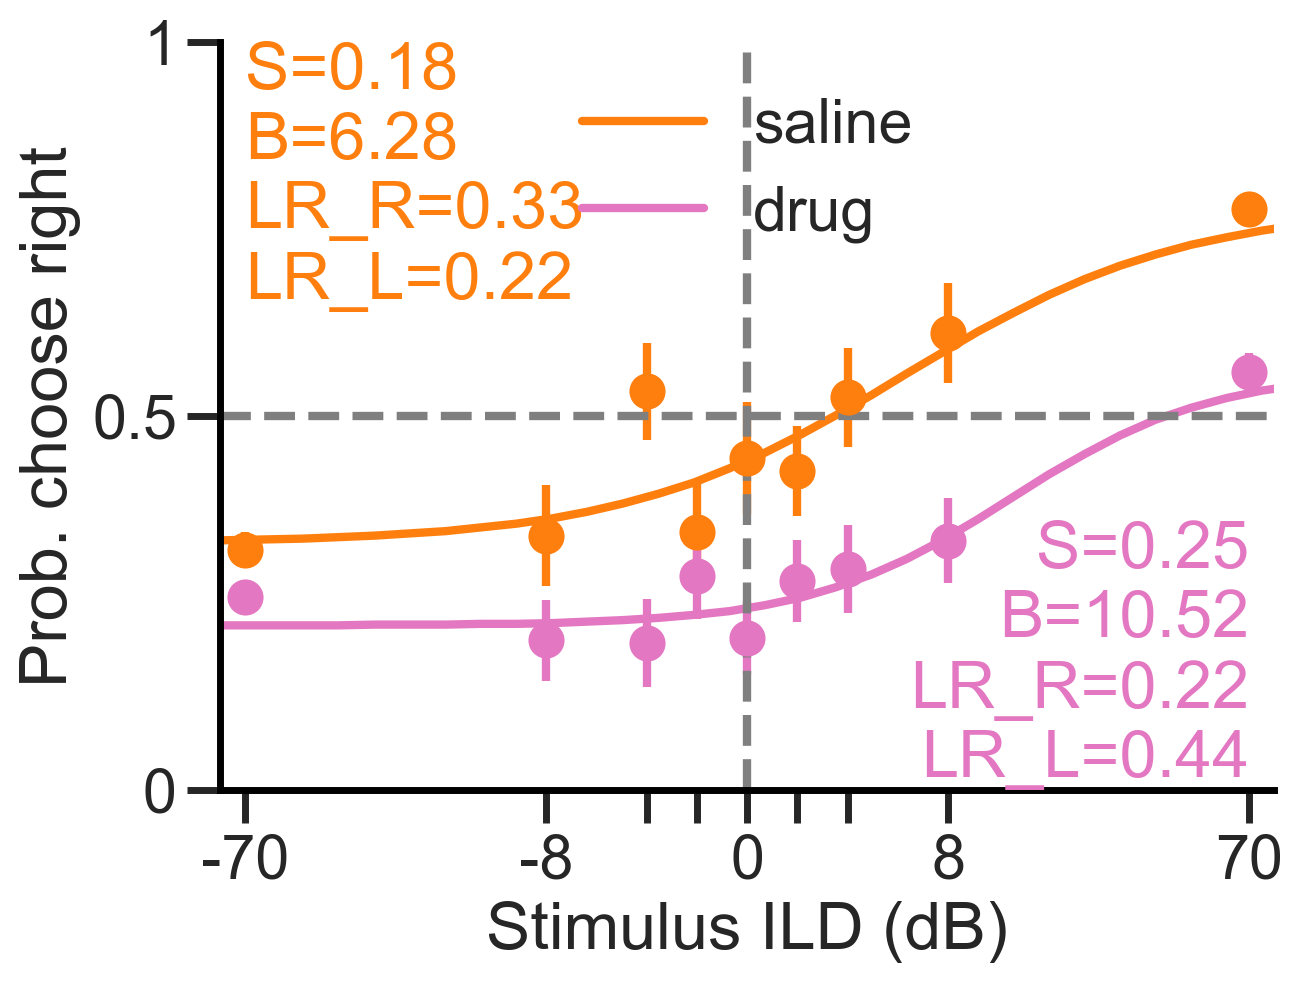

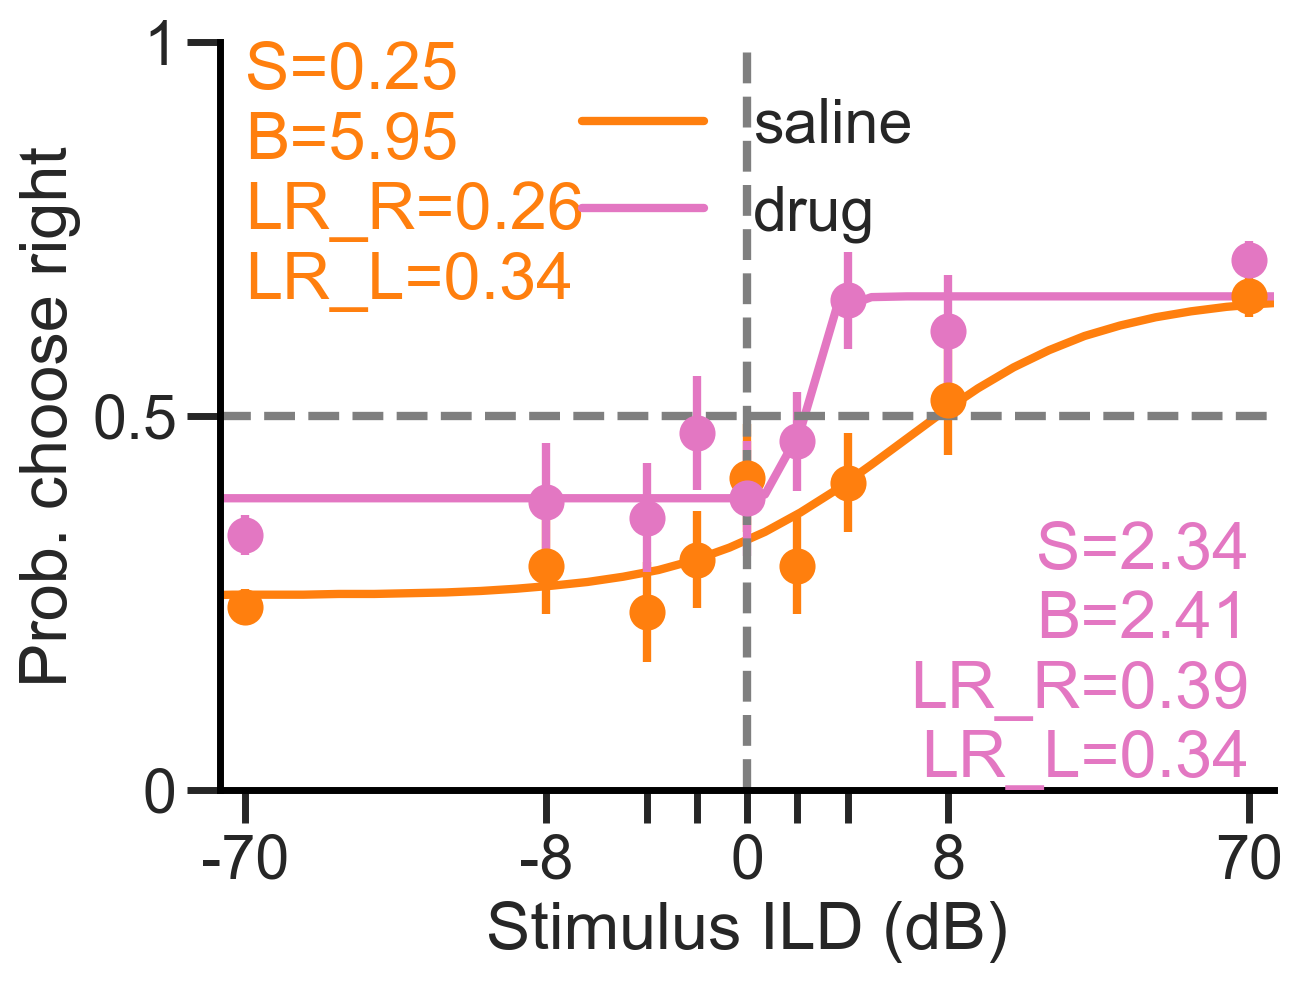

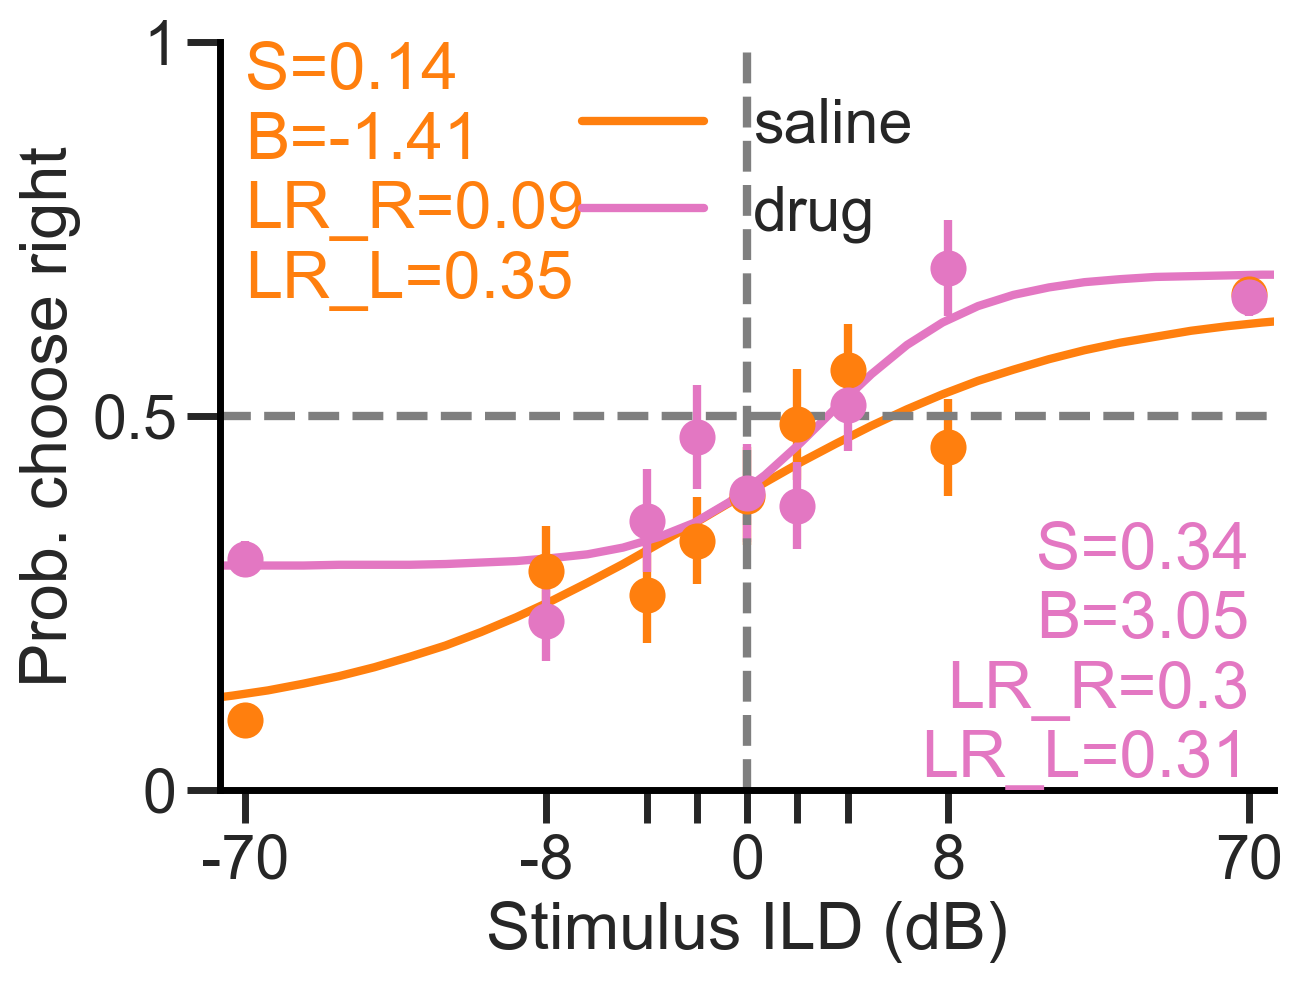

In [10]:
for animal in animals:
    print(f'Animal {animal}')
    plot_pc_drug(experiment='2AFC_6', animal=animal, kind=kind)


#### Mean across animals

plot_mean_pc took 8.70 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:488: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame(params, columns=columns)], ignore_index=True)


plot_mean_pc took 8.71 seconds to run
plot_mean_pc_drug took 17.44 seconds to run


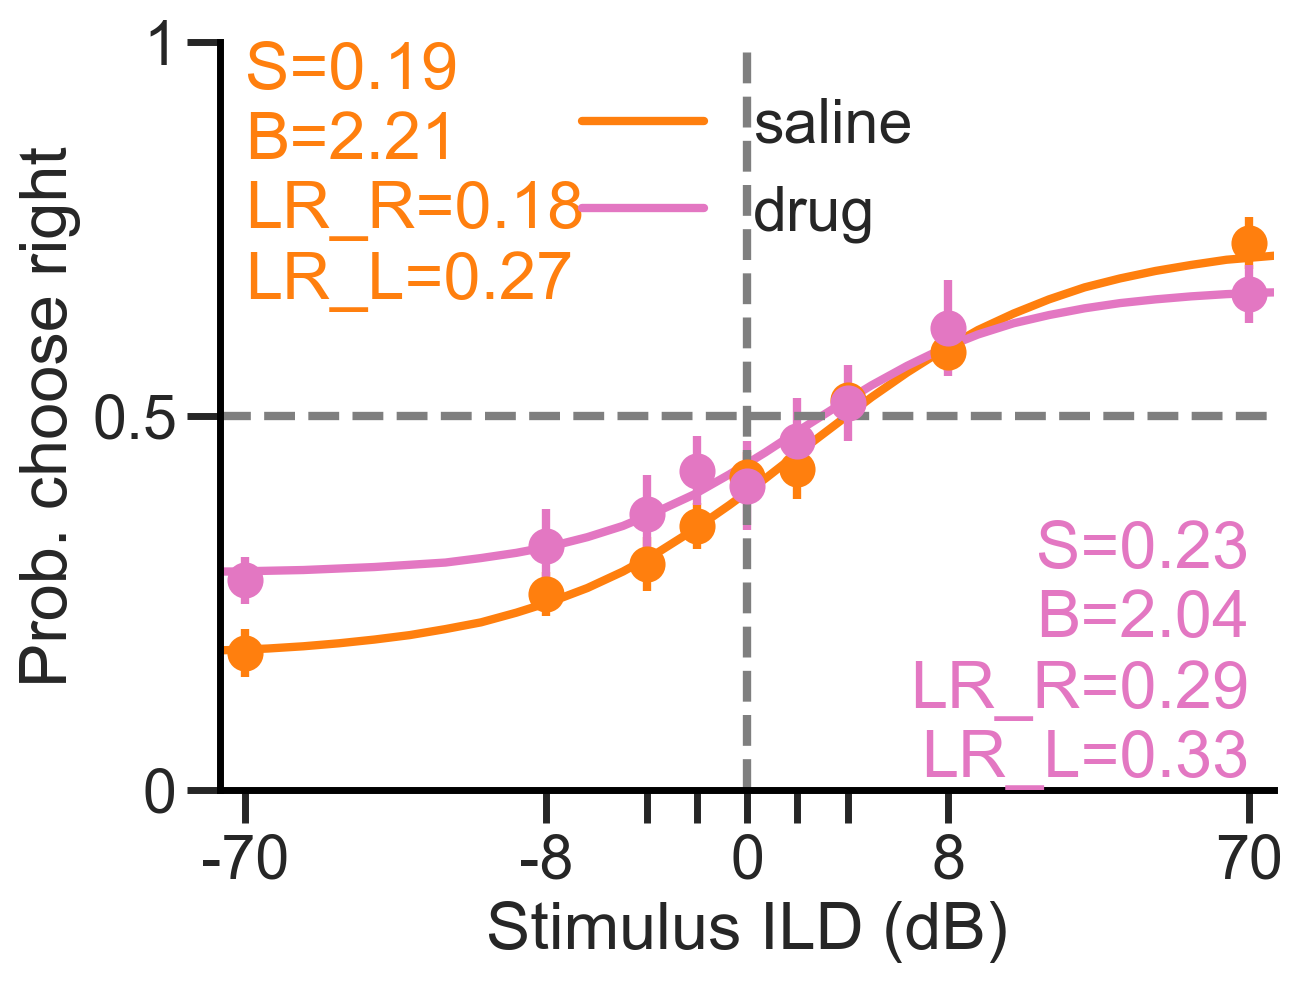

In [11]:
params = plot_mean_pc_drug(experiment='2AFC_6', animals=animals, kind=kind)

##### Stats

sensitivity: t-statistic = -1.150, p-value = 0.267
bias: t-statistic = 0.063, p-value = 0.950
lr_right: t-statistic = -2.257, p-value = 0.038
lr_left: t-statistic = -1.084, p-value = 0.294


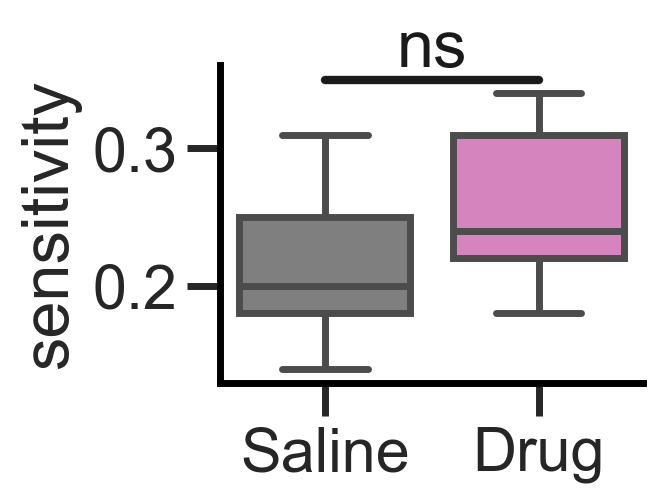

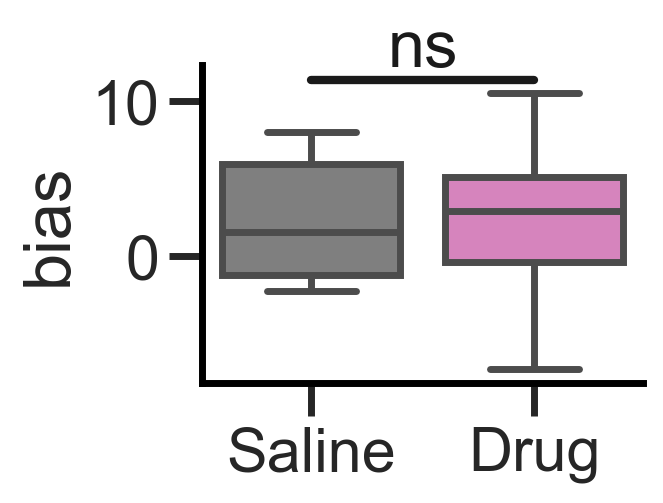

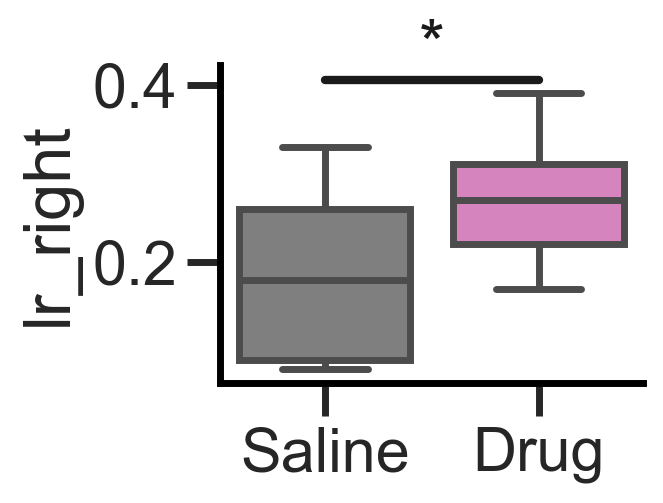

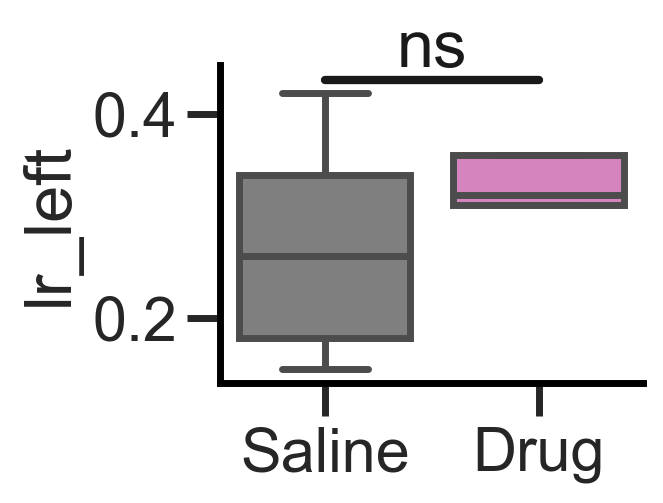

In [12]:
compare_psych_params(params, 'sensitivity')
compare_psych_params(params, 'bias')
compare_psych_params(params, 'lr_right')
compare_psych_params(params, 'lr_left')

### Probability choose REPAT

In [13]:
kind = 'prob_rep'

#### Single animals

Animal 014
plot_pc took 1.09 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 1.00 seconds to run
plot_pc_drug took 2.11 seconds to run
Animal 016
plot_pc took 1.11 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 1.07 seconds to run
plot_pc_drug took 2.20 seconds to run
Animal 017
plot_pc took 1.15 seconds to run


...

plot_pc took 0.88 seconds to run
plot_pc_drug took 1.77 seconds to run
Animal 024
plot_pc took 0.86 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 0.83 seconds to run
plot_pc_drug took 1.70 seconds to run
Animal 025
plot_pc took 0.83 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:393: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame([params], columns=columns)], ignore_index=True)


plot_pc took 0.93 seconds to run
plot_pc_drug took 1.78 seconds to run


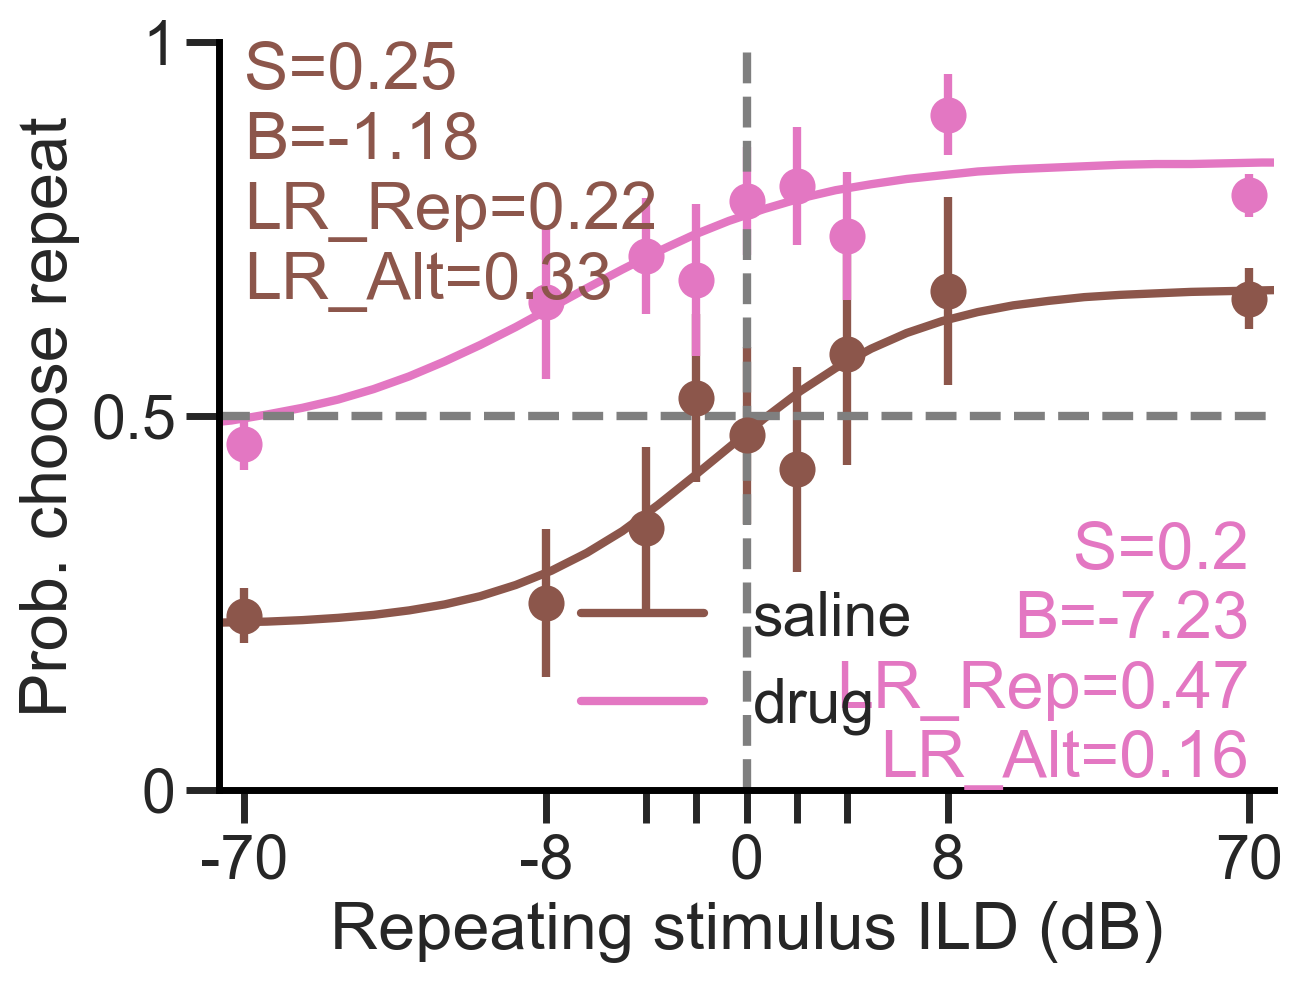

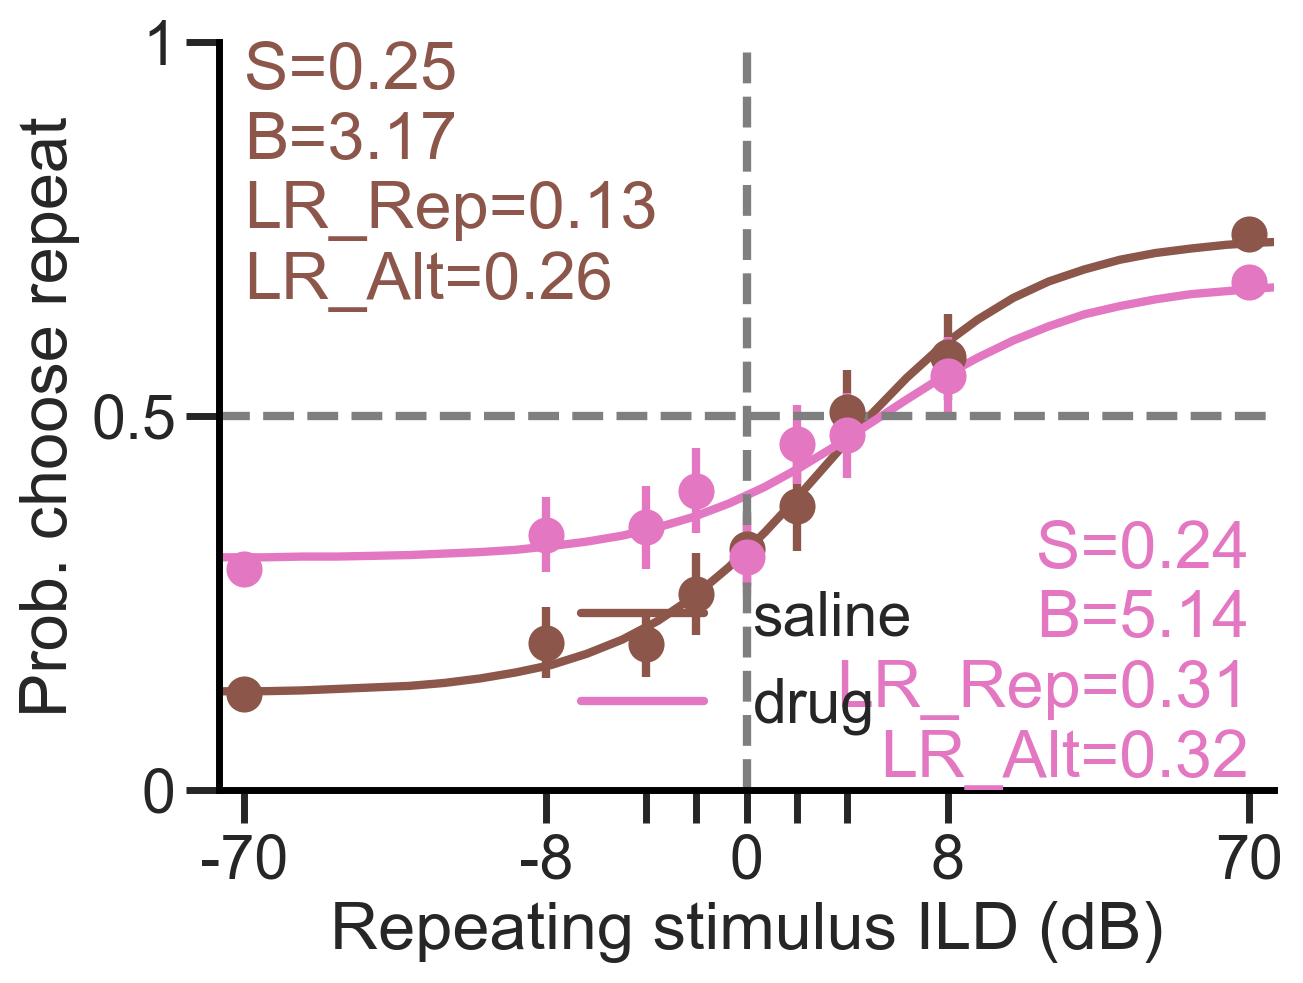

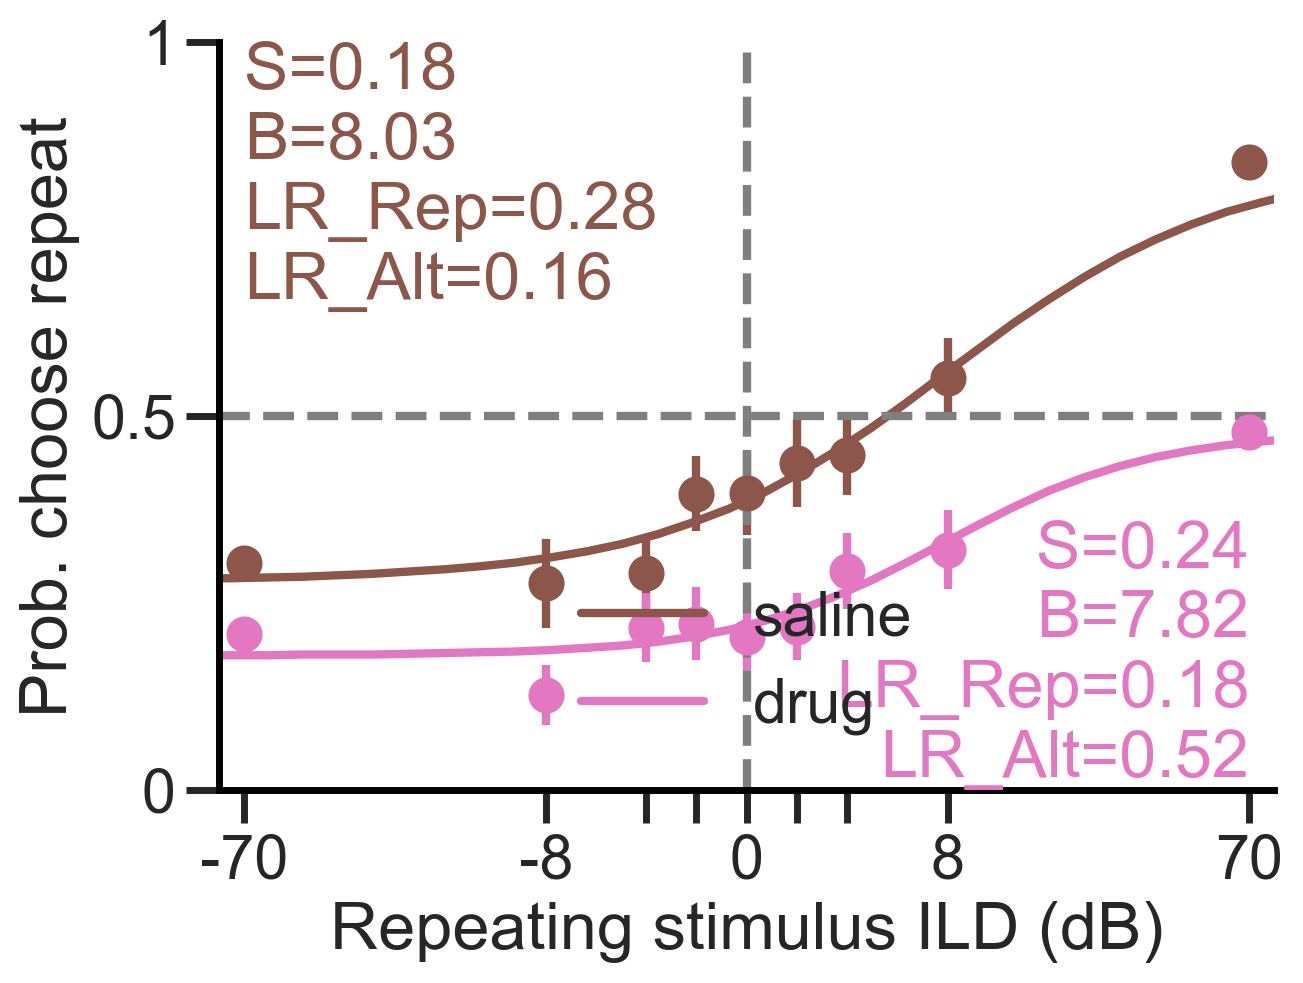

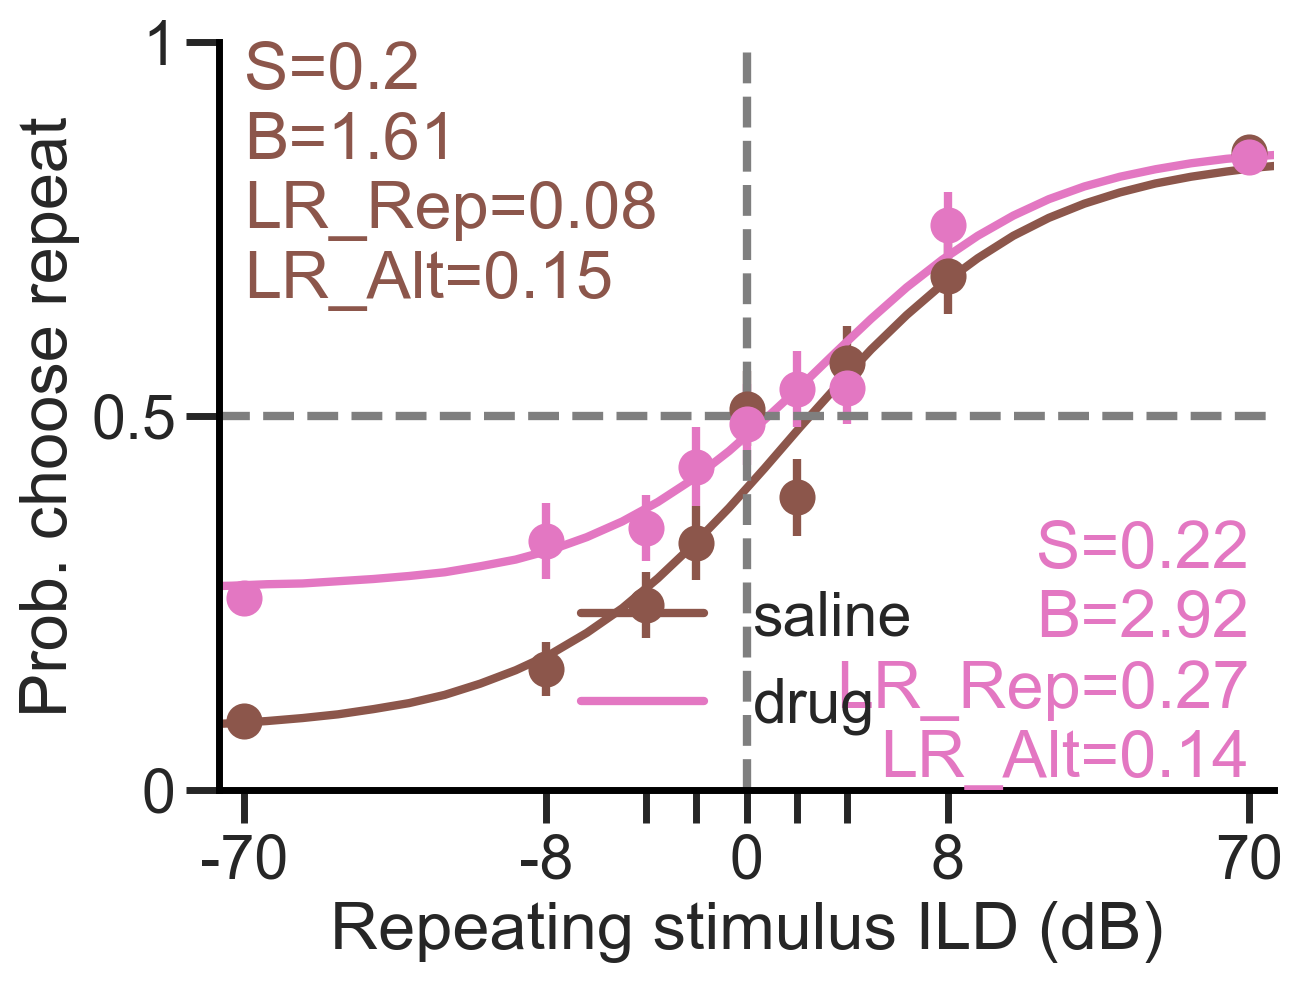

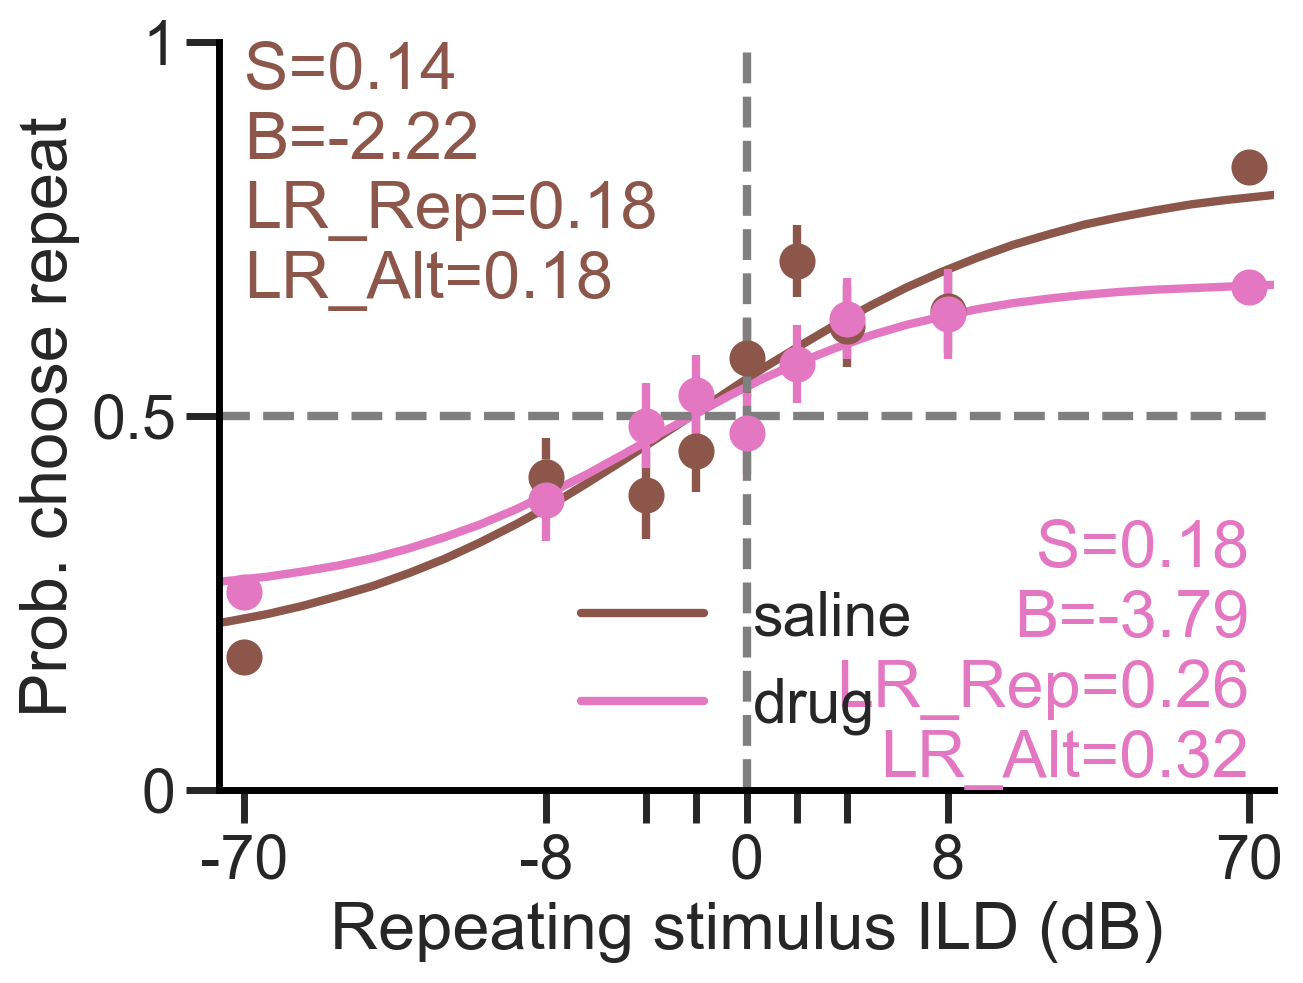

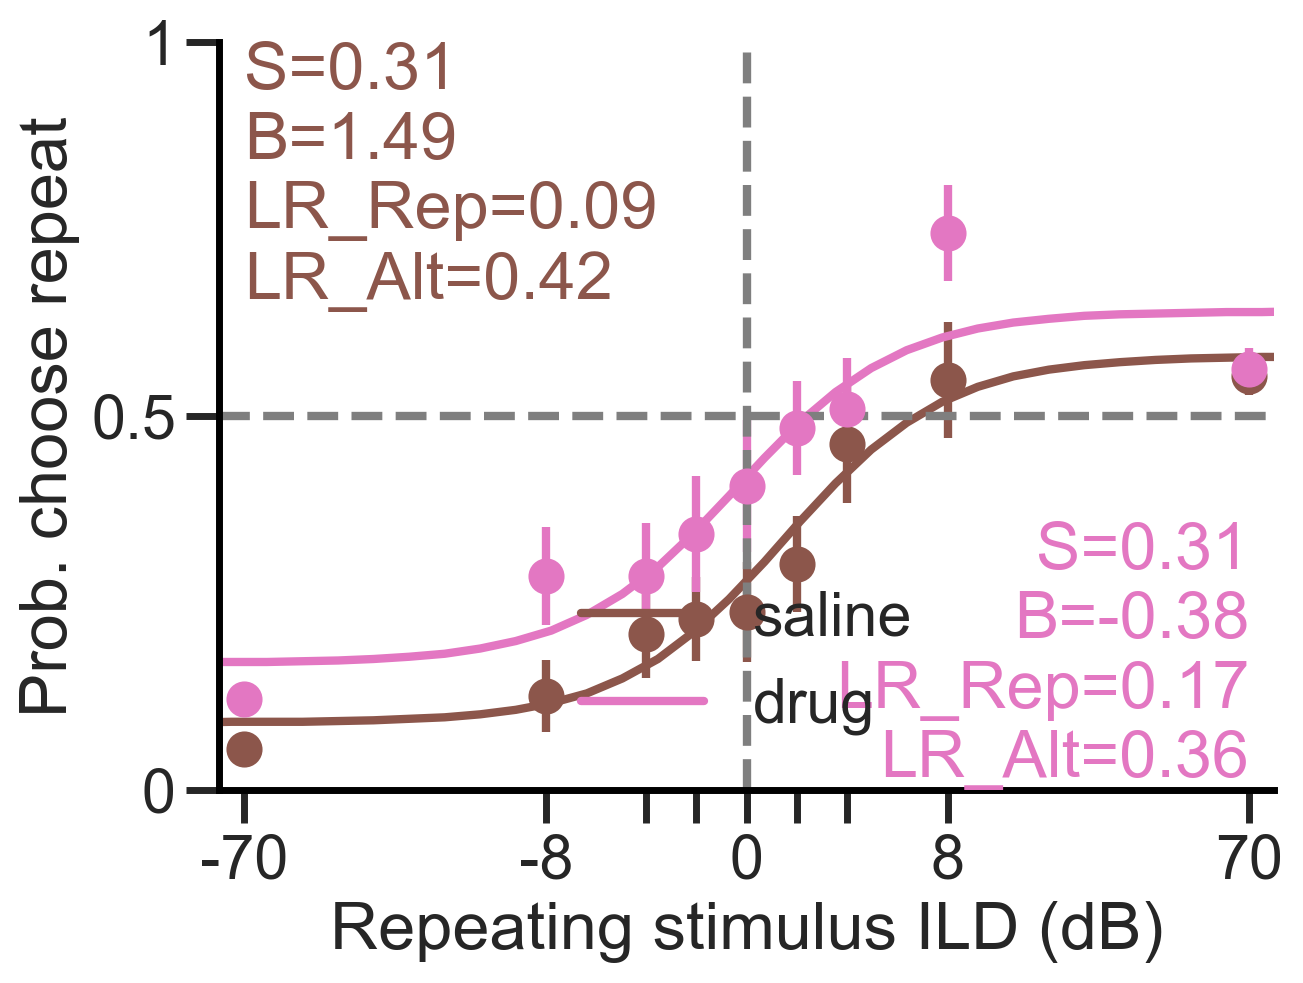

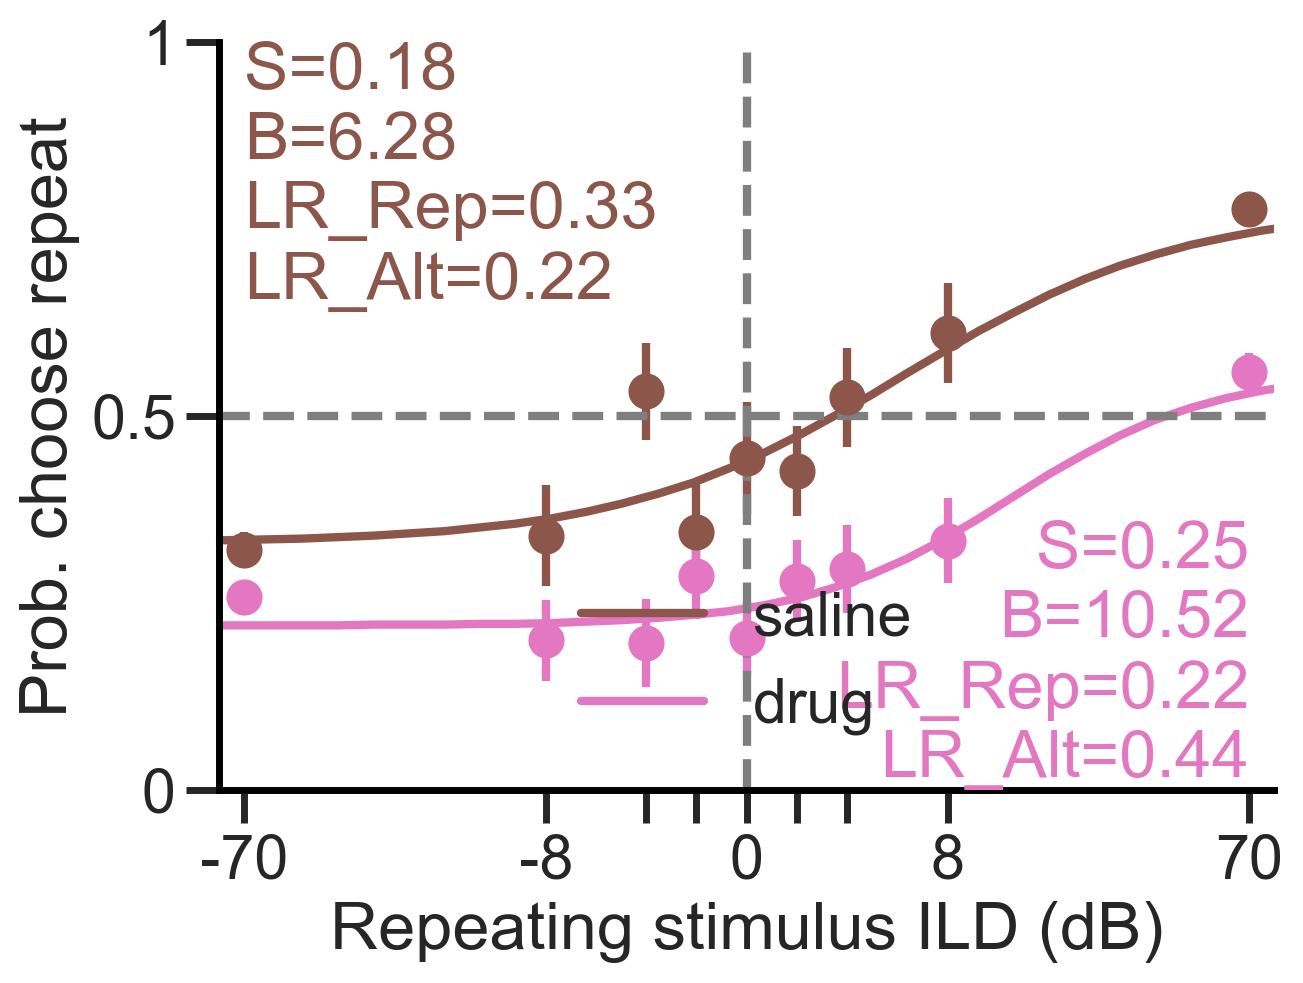

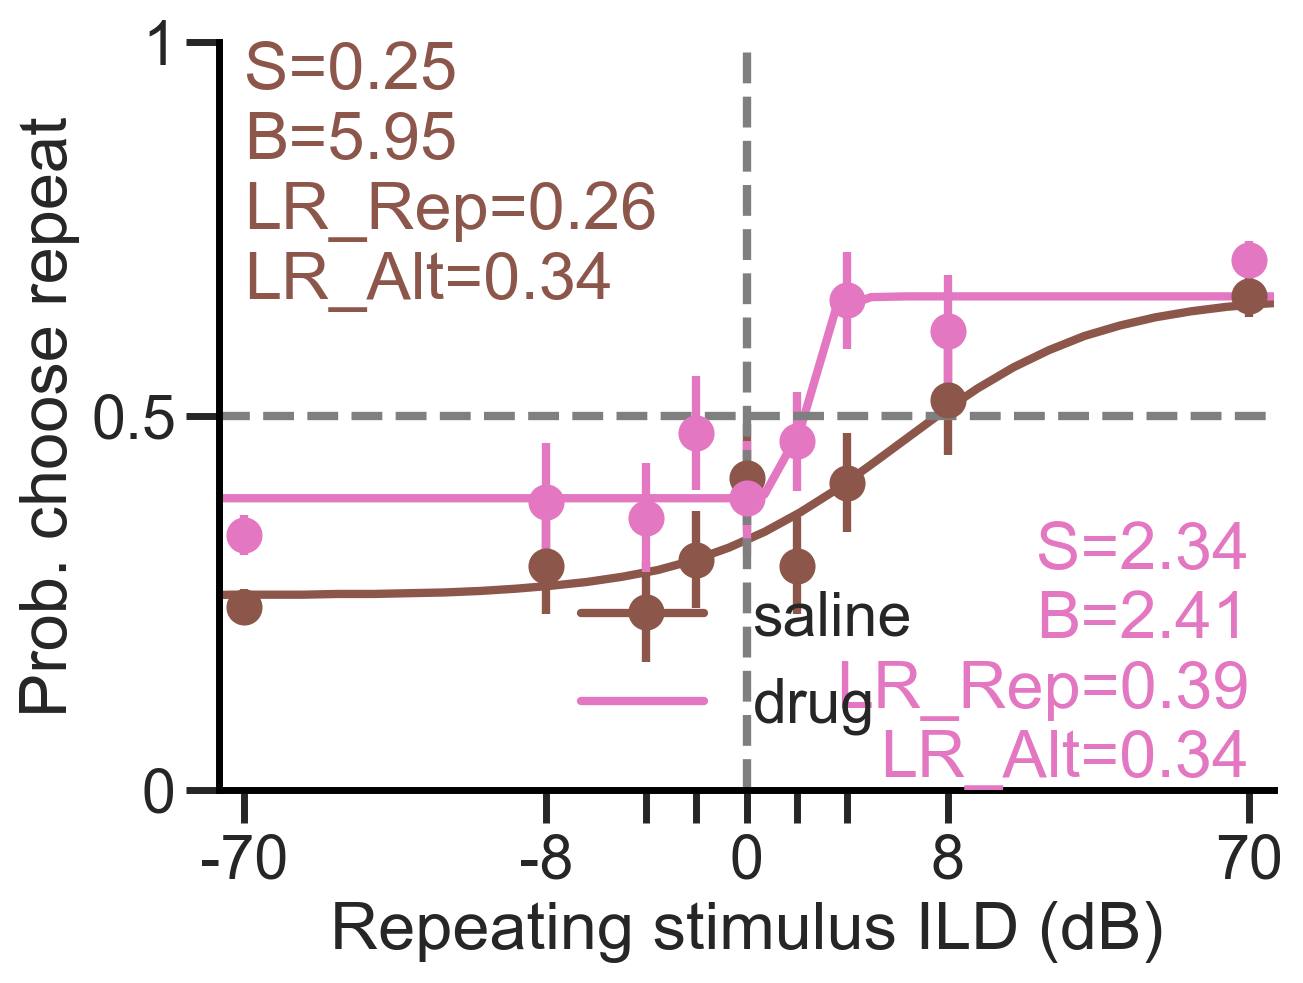

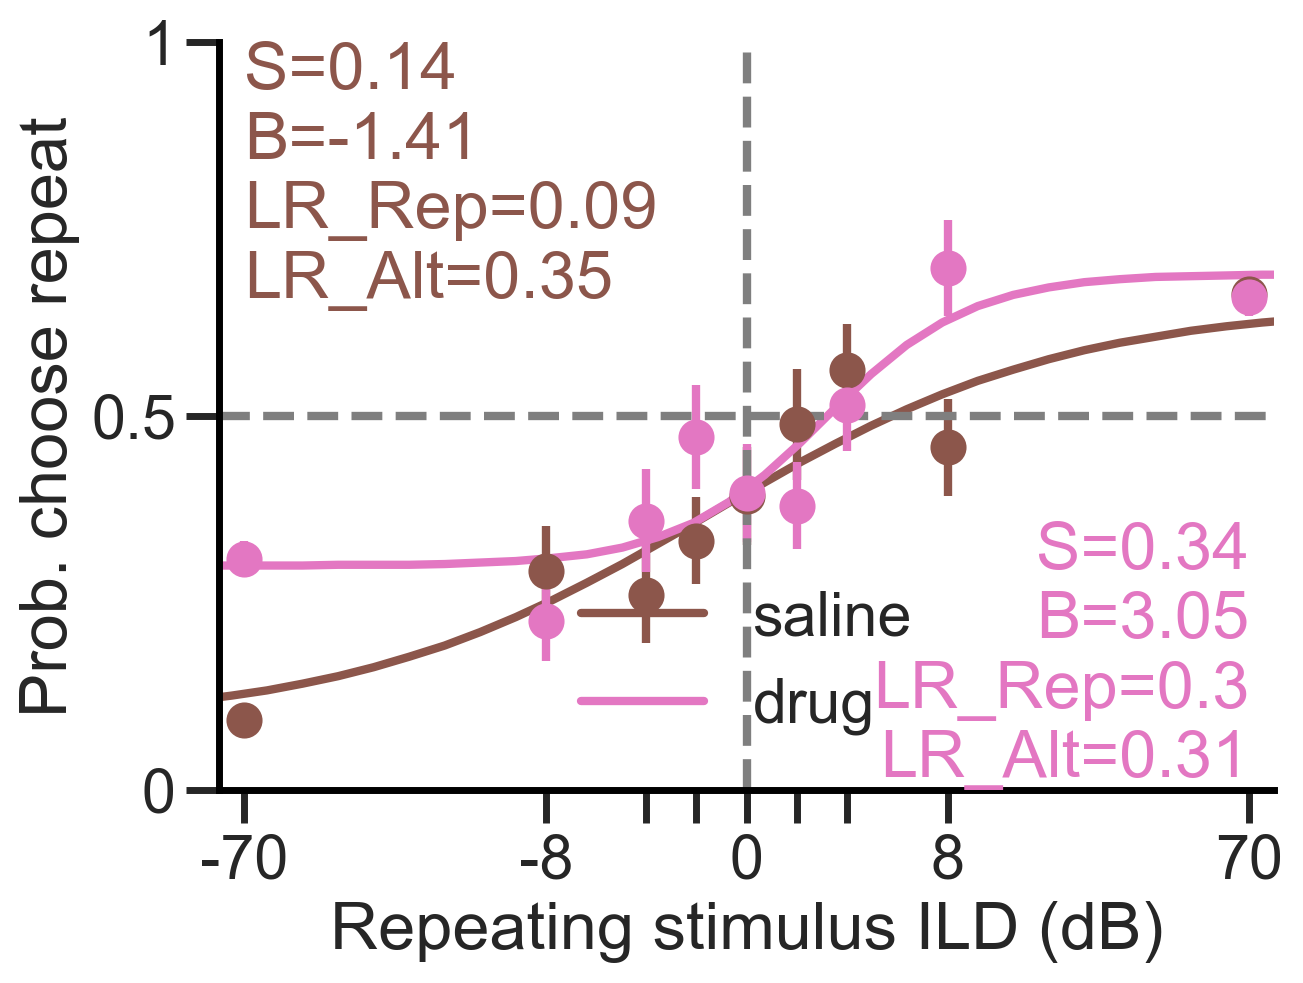

In [14]:
for animal in animals:
    print(f'Animal {animal}')
    plot_pc_drug(experiment='2AFC_6', animal=animal, kind=kind)

#### Mean across animals

plot_mean_pc took 8.71 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:488: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame(params, columns=columns)], ignore_index=True)


plot_mean_pc took 9.02 seconds to run
plot_mean_pc_drug took 17.75 seconds to run


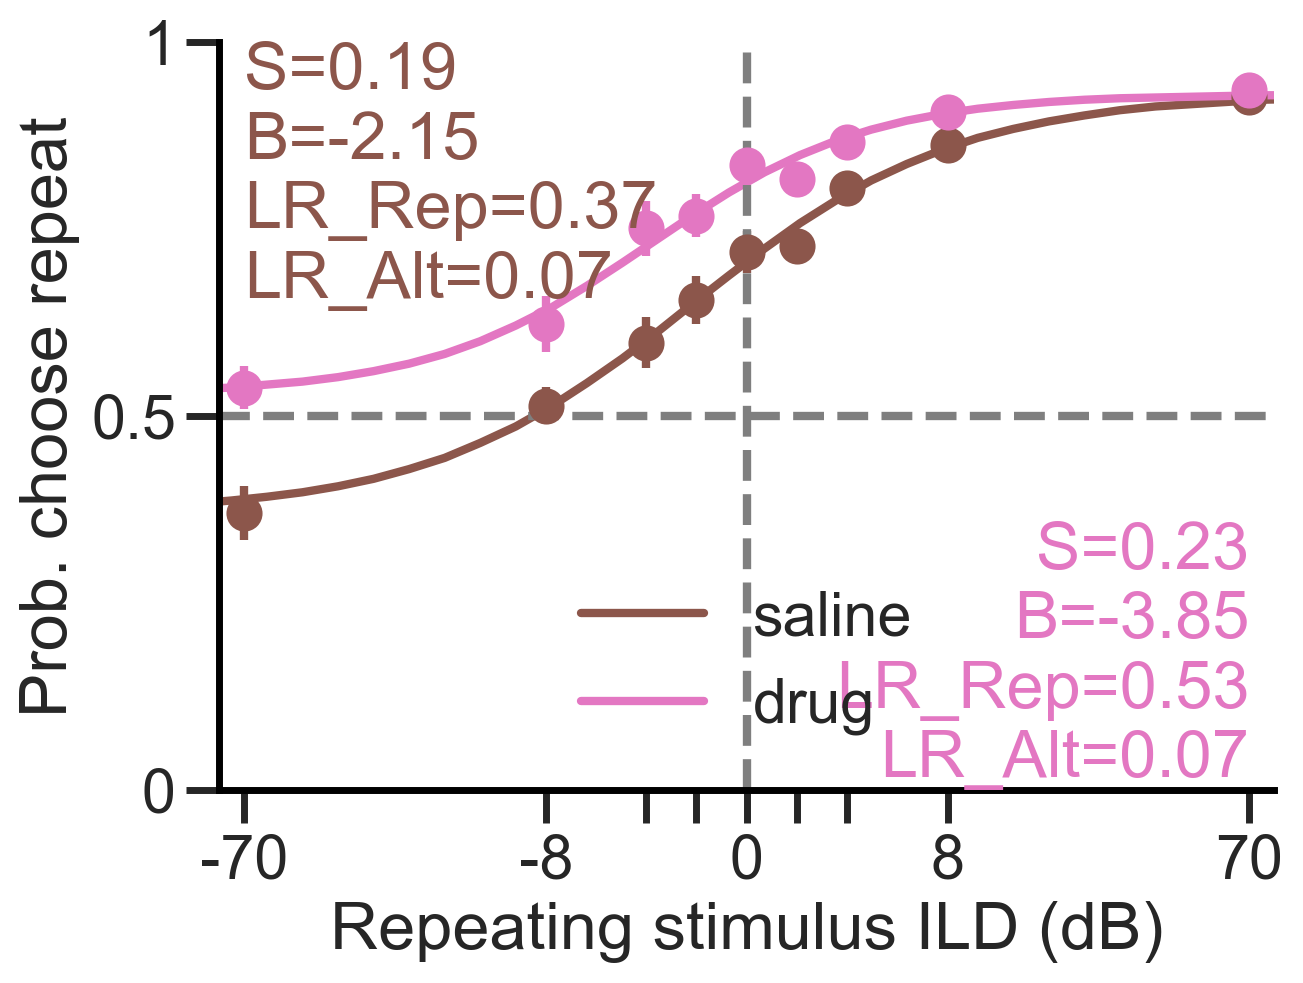

In [15]:
params = plot_mean_pc_drug(experiment='2AFC_6', animals=animals, kind=kind)

##### Stats

sensitivity: t-statistic = -1.894, p-value = 0.077
bias: t-statistic = 1.489, p-value = 0.156
lr_rep: t-statistic = -3.784, p-value = 0.002
lr_alt: t-statistic = -0.400, p-value = 0.695


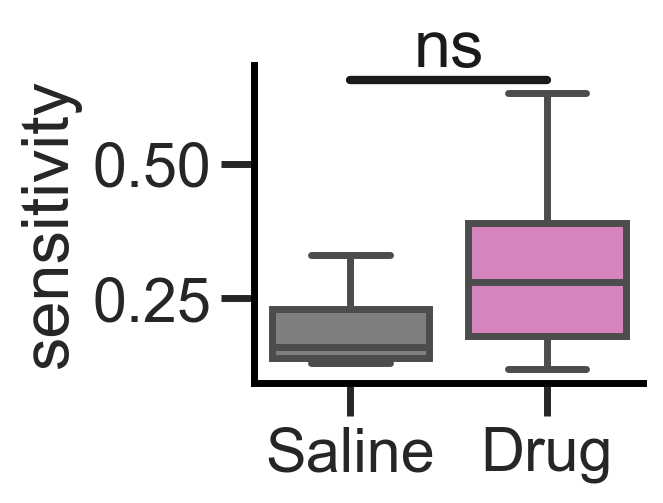

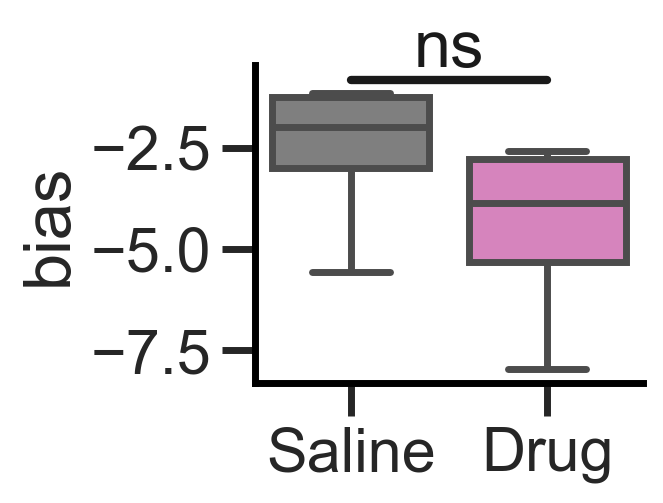

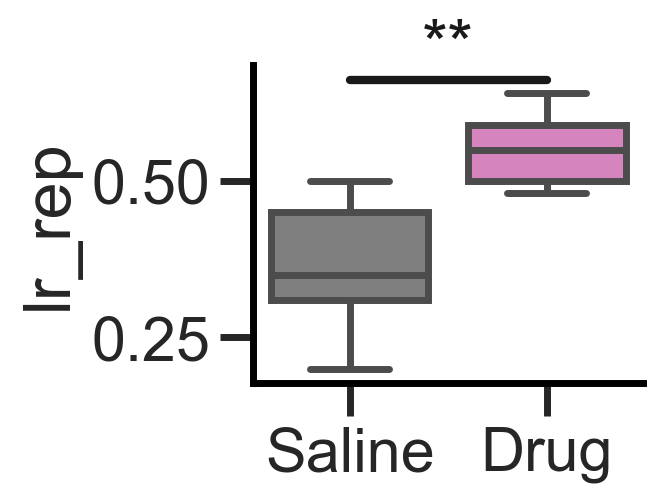

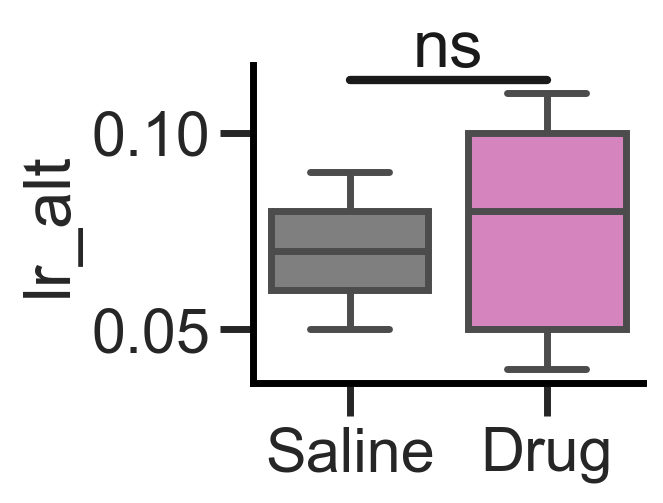

In [16]:
compare_psych_params(params, 'sensitivity')
compare_psych_params(params, 'bias')
compare_psych_params(params, 'lr_rep')
compare_psych_params(params, 'lr_alt')

## Kernels

### Pshycophisical kernels

### History kernels